$$ \textbf{Central Limit Theorem Simulation} $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

This is a perfect example of using **computational simulation** to understand statistical theory.

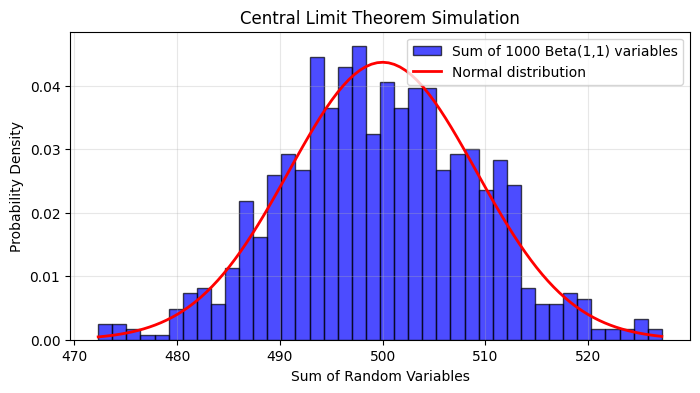

Sample mean: 499.786 (theoretical: 500.0)
Sample std: 9.379 (theoretical: 9.129)


In [ ]:
# Method 1: Using list comprehension
np.random.seed(42)  # for reproducibility

# n_per_sample (sample size within each group): How many random variables we sum together
# As n_per_sample increases, the distribution of the sum becomes more normal
n_per_sample = 1000 

# n_samples (number of groups): How many sums we compute to build histogram.
# This just determines how smooth the histogram looks
n_samples = 900

# Sum 1000 Beta variables → approximately normal
# Take 900 such sums to see the distribution
# Generating artificial data
container = [np.sum(np.random.beta(1, 1, n_per_sample)) for _ in range(n_samples)]

# Method 2: Using numpy array (more efficient)
# container = np.zeros(n_samples)
# for i in range(n_samples):
#     container[i] = np.sum(np.random.beta(1, 1, n_per_sample))

# Plot
plt.figure(figsize=(8, 4))
# Normalizes the histogram so the total area under the bars equals 1 (probability density), rather than showing raw counts
plt.hist(container, bins=40, density=True, alpha=0.7, 
         label='Sum of 1000 Beta(1,1) variables', color='blue', edgecolor='black')

# Theoretical normal distribution parameters
# Beta(1,1) = Uniform(0,1): mean=0.5, variance=1/12 ≈ 0.08333
# The sum of 1000 i.i.d. Beta(1,1) variables approaches a Normal distribution with:
mu = 1000 * 0.5  
sigma = np.sqrt(1000 * (1/12)) 

# Overlay theoretical normal distribution
x_range = np.linspace(min(container), max(container), 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 
         linewidth=2, label='Normal distribution', color='red')

plt.xlabel('Sum of Random Variables')
plt.ylabel('Probability Density')
plt.title('Central Limit Theorem Simulation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print summary statistics
print(f"Sample mean: {np.mean(container):.3f} (theoretical: {mu})")
print(f"Sample std: {np.std(container):.3f} (theoretical: {sigma:.3f})")

This Simulation (Monte Carlo Simulation) clearly demonstrates how the sum (or mean) of many i.i.d. variables (even from a non-normal Beta distribution) approximates a normal distribution.

This simulation is a numerical experiment that demonstrates the Central Limit Theorem through Monte Carlo Simulation. It replaces mathematical proof with computational evidence, which is especially valuable for:

*  Checking theoretical results

*  Exploring conditions where theory might break down

*  Estimating quantities when analytical solutions are impossible